# Notebook 5 — controls and heterogeneity Analysis

Analysing control variables and heterogeneity across crisis periods, sectors, and regions.

**Steps performed:**
1. Control variables: war, COVID, and frontline dummies by proxy and sector
2. Year-over-year heatmap of financial indicators — all observations and crisis years by credit access
3. Crisis years heatmap by sector — Y3=1 and Y3=0 separately
4. Share of firms with increasing credit in crisis years by sector
5. Regional credit access before and after the full-scale war
6. Frontline dummy analysis by sector

**Input:** `df_cleaned.csv` from Notebook 1. Dependent variables and indicators mirror Notebooks 3–4.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from scipy.stats.mstats import winsorize

## 0. Loading data, chart style and constants

In [2]:
df = pd.read_csv('df_cleaned.csv', sep=';', encoding='utf-8', low_memory=False)
print('Dataset shape:', df.shape)

Dataset shape: (81062, 167)


In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams.update({
    'figure.facecolor': 'white', 'figure.dpi': 150,
    'font.family': 'serif', 'font.serif': ['Georgia', 'Times New Roman', 'DejaVu Serif'],
    'font.size': 11, 'axes.facecolor': 'white', 'axes.edgecolor': '#2c2c2c',
    'axes.linewidth': 0.8, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.titlepad': 14, 'axes.labelsize': 11, 'axes.labelcolor': '#2c2c2c',
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#e0e0e0', 'grid.linewidth': 0.6, 'grid.linestyle': '--',
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'xtick.color': '#2c2c2c', 'ytick.color': '#2c2c2c',
    'legend.fontsize': 10, 'legend.framealpha': 0.9, 'legend.edgecolor': '#cccccc',
    'lines.linewidth': 2, 'lines.markersize': 7,
    'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})

COLORS = {
    'primary': '#2c5f8a', 'secondary': '#4a9aba', 'positive': '#3ab5a5',
    'negative': '#d9534f', 'neutral': '#95a5a6', 'accent': '#f0c060', 'light': '#ddeef7',
}

In [4]:
SECTOR_MAP = {
    'A': 'Agriculture', 'B': 'Mining', 'C': 'Manufacturing', 'D': 'Energy',
    'E': 'Water & Waste', 'F': 'Construction', 'G': 'Wholesale & Retail Trade',
    'H': 'Transportation', 'I': 'Accommodation & Food', 'J': 'Information & Communication',
    'K': 'Financial Services', 'L': 'Real Estate', 'M': 'Professional Services',
    'N': 'Administrative Services', 'O': 'Public Administration', 'P': 'Education',
    'Q': 'Health & Social Work', 'R': 'Arts & Entertainment', 'S': 'Other Services',
}
TOP_SECTORS  = ['Wholesale & Retail Trade', 'Manufacturing', 'Agriculture', 'Energy', 'Mining']
SECTOR_ORDER = ['Agriculture', 'Manufacturing', 'Wholesale & Retail Trade', 'Energy', 'Mining', 'Other']
SECTOR_COLORS = {
    'Agriculture': COLORS['negative'], 'Manufacturing': COLORS['positive'],
    'Wholesale & Retail Trade': COLORS['primary'], 'Energy': COLORS['accent'],
    'Mining': COLORS['secondary'], 'Other': COLORS['neutral'],
}

FRONTLINE_2014 = ['Донецька область', 'Луганська область']
FRONTLINE_2022 = ['Харківська область', 'Запорізька область', 'Херсонська область',
                  'Миколаївська область', 'Чернігівська область', 'Сумська область']

MAIN_DEP_VAR = 'Y3_Increasing_Credit'
ALL_DEP_VARS = [
    ('Y1_Has_Credit',         'Y1: Has Credit'),
    ('Y2_Active_Credit_User', 'Y2: Active Credit User'),
    ('Y3_Increasing_Credit',  'Y3: Increasing Credit'),
]

HEATMAP_COLORS = [
    '#c0392b', '#e74c3c', '#f1948a', '#fadbd8', '#fdfefe',
    '#d6eaf8', '#7fb3d3', '#2e86c1', '#1a5276', '#0d2b45'
]
SECTOR_SHORT = {
    'Agriculture': 'Agri', 'Manufacturing': 'Manuf',
    'Wholesale & Retail Trade': 'W&R', 'Energy': 'Energy',
    'Mining': 'Mining', 'Other': 'Other',
}
PREV_YEARS  = {2020: 2019, 2022: 2021}
SUM_COLS    = ['NetDebt_to_EBITDA_w', 'Debt_to_Assets_w']

In [5]:
# Reconstruct dependent variables and group assignments
df = df.sort_values(['Firm ID', 'Year']).reset_index(drop=True)

df['Y1_Has_Credit'] = (df['Total Debt'].fillna(0) > 0).astype(float)

df_lag = df[['Firm ID', 'Year', 'Total Debt']].copy()
df_lag['Year'] = df_lag['Year'] + 1
df_lag = df_lag.rename(columns={'Total Debt': 'Total_Debt_lag1'})
df = df.merge(df_lag, on=['Firm ID', 'Year'], how='left')

df['Debt_Change']     = df['Total Debt'] - df['Total_Debt_lag1']
df['Debt_Change_pct'] = df['Debt_Change'] / df['Total_Debt_lag1'].replace(0, float('nan'))

df['Y3_Increasing_Credit'] = (df['Debt_Change'] > 0).astype(float)
df.loc[df['Total_Debt_lag1'].isna(), 'Y3_Increasing_Credit'] = float('nan')

df['Y2_Active_Credit_User'] = 1.0
df.loc[df['Total Debt'].fillna(0) == 0, 'Y2_Active_Credit_User'] = 0.0
df.loc[df['Debt_Change_pct'] < -0.20, 'Y2_Active_Credit_User'] = 0.0
df.loc[df['Total_Debt_lag1'].isna(), 'Y2_Active_Credit_User'] = float('nan')

df['Sector Label'] = df['Sector'].map(SECTOR_MAP)
df['Sector Group'] = df['Sector Label'].apply(lambda x: x if x in TOP_SECTORS else 'Other')

# Control dummies
df['War_Dummy']      = (df['Year'] == 2022).astype(int)
df['COVID_Dummy']    = (df['Year'] == 2020).astype(int)
df['Frontline_2014'] = df['Region'].isin(FRONTLINE_2014).astype(int)
df['Frontline_2022'] = (df['Region'].isin(FRONTLINE_2022) & (df['Year'] >= 2022)).astype(int)

print(f'df: {df.shape}')

df: (81062, 179)


In [6]:
# Reconstruct winsorised financial indicators (mirrors Notebook 5)
df['log_Total_Assets'] = np.log(df['Total Assets'].replace(0, np.nan))
df['log_Net_Revenue']  = np.log(df['Net Revenue'].replace(0, np.nan))
df['EBIT_Margin']   = df['EBIT']              / df['Net Revenue'].replace(0, np.nan)
df['EBITDA_Margin'] = df['EBITDA']            / df['Net Revenue'].replace(0, np.nan)
df['PBT_Margin']    = df['Profit Before Tax'] / df['Net Revenue'].replace(0, np.nan)
df['ROA']           = df['Net Income']         / df['Total Assets'].replace(0, np.nan)
df['GP_Margin']     = df['Gross Profit']       / df['Net Revenue'].replace(0, np.nan)
df['Current_Ratio'] = df['Total Current Assets']      / df['Total Current Liabilities'].replace(0, np.nan)
df['Quick_Ratio']   = (df['Total Current Assets'] - df['Inventories']) / df['Total Current Liabilities'].replace(0, np.nan)
df['Cash_Ratio']    = df['Cash and Cash Equivalents'] / df['Total Current Liabilities'].replace(0, np.nan)
df['Equity_Ratio']      = df['Total Equity'] / df['Total Assets'].replace(0, np.nan)
df['NetDebt_to_EBITDA'] = df['Net Debt']      / df['EBITDA'].replace(0, np.nan)
df['Debt_to_Assets']    = df['Total Debt']    / df['Total Assets'].replace(0, np.nan)
df['ICR_EBIT']      = df['EBIT'] / df['Financial Expenses'].replace(0, np.nan)
df['Tangibility']   = df['PPE'] / df['Total Assets'].replace(0, np.nan)
df['Asset_Turnover'] = df['Net Revenue']        / df['Total Assets'].replace(0, np.nan)
df['Inventory_Days'] = df['Inventories']         * 365 / df['COGS'].replace(0, np.nan)
df['AR_Days']        = df['Accounts Receivable'] * 365 / df['Net Revenue'].replace(0, np.nan)
df['AP_Days']        = df['Accounts Payable']    * 365 / df['COGS'].replace(0, np.nan)
df['WC_to_Assets']  = (df['Total Current Assets'] - df['Total Current Liabilities']) / df['Total Assets'].replace(0, np.nan)

WINSOR_99 = ['log_Total_Assets', 'log_Net_Revenue', 'Tangibility']
WINSOR_95 = [
    'EBIT_Margin', 'EBITDA_Margin', 'PBT_Margin', 'ROA', 'GP_Margin',
    'Current_Ratio', 'Quick_Ratio', 'Cash_Ratio',
    'Equity_Ratio', 'NetDebt_to_EBITDA', 'Debt_to_Assets',
    'ICR_EBIT', 'Asset_Turnover', 'Inventory_Days', 'AR_Days', 'AP_Days', 'WC_to_Assets',
]
for col in WINSOR_99:
    mask = df[col].notna()
    df.loc[mask, col + '_w'] = winsorize(df.loc[mask, col], limits=[0.01, 0.01])
for col in WINSOR_95:
    mask = df[col].notna()
    df.loc[mask, col + '_w'] = winsorize(df.loc[mask, col], limits=[0.05, 0.05])

FIN_COLS_W = [
    'log_Total_Assets_w', 'log_Net_Revenue_w',
    'EBIT_Margin_w', 'EBITDA_Margin_w', 'PBT_Margin_w', 'ROA_w', 'GP_Margin_w',
    'Current_Ratio_w', 'Quick_Ratio_w', 'Cash_Ratio_w',
    'Equity_Ratio_w', 'NetDebt_to_EBITDA_w', 'Debt_to_Assets_w',
    'ICR_EBIT_w', 'Tangibility_w',
    'Asset_Turnover_w', 'Inventory_Days_w', 'AR_Days_w', 'AP_Days_w', 'WC_to_Assets_w',
]
FIN_COLS_LABELS = {
    'log_Total_Assets_w': 'log(Total Assets)', 'log_Net_Revenue_w': 'log(Net Revenue)',
    'EBIT_Margin_w': 'EBIT Margin', 'EBITDA_Margin_w': 'EBITDA Margin',
    'PBT_Margin_w': 'PBT Margin', 'ROA_w': 'ROA', 'GP_Margin_w': 'GP Margin',
    'Current_Ratio_w': 'Current Ratio', 'Quick_Ratio_w': 'Quick Ratio',
    'Cash_Ratio_w': 'Cash Ratio', 'Equity_Ratio_w': 'Equity Ratio',
    'NetDebt_to_EBITDA_w': 'Net Debt / EBITDA', 'Debt_to_Assets_w': 'Debt to Assets',
    'ICR_EBIT_w': 'ICR (EBIT)', 'Tangibility_w': 'Tangibility',
    'Asset_Turnover_w': 'Asset Turnover', 'Inventory_Days_w': 'Inventory Days',
    'AR_Days_w': 'AR Days', 'AP_Days_w': 'AP Days', 'WC_to_Assets_w': 'WC / Total Assets',
}

print('Indicators reconstructed.')

Indicators reconstructed.


## 1. Control variables — by dependent variable and sector

Reporting credit access rates split by war, COVID, and frontline dummies — first across all three dependent variables, then broken down by sector for Y3.

In [7]:
CONTROL_VARS = [
    ('War_Dummy',      'War Shock (2022)'),
    ('COVID_Dummy',    'COVID (2020)'),
    ('Frontline_2014', 'Frontline since 2014'),
    ('Frontline_2022', 'Frontline from 2022'),
]

print('CONTROLS — By Dependent Variable')
for col, label in CONTROL_VARS:
    print(f'\n{label}')
    print('-' * 65)
    rows = []
    for var, var_label in ALL_DEP_VARS:
        temp    = df[[col, var]].dropna()
        share_1 = temp[temp[col] == 1][var].mean() * 100
        share_0 = temp[temp[col] == 0][var].mean() * 100
        rows.append({
            'Variable'             : var_label,
            'Credit=1 % (dummy=1)' : round(share_1, 1),
            'Credit=1 % (dummy=0)' : round(share_0, 1),
            'Difference'           : round(share_1 - share_0, 1),
        })
    print(pd.DataFrame(rows).to_string(index=False))

print('\n\nCONTROLS — By Sector (Y3 only)')
for col, label in CONTROL_VARS:
    print(f'\n{label}')
    print('-' * 65)
    rows = []
    for sector in SECTOR_ORDER:
        temp    = df[df['Sector Group'] == sector][[col, MAIN_DEP_VAR]].dropna()
        share_1 = temp[temp[col] == 1][MAIN_DEP_VAR].mean() * 100
        share_0 = temp[temp[col] == 0][MAIN_DEP_VAR].mean() * 100
        n_1     = len(temp[temp[col] == 1])
        rows.append({
            'Sector'               : sector,
            'N (dummy=1)'          : n_1,
            'Credit=1 % (dummy=1)' : round(share_1, 1),
            'Credit=1 % (dummy=0)' : round(share_0, 1),
            'Difference'           : round(share_1 - share_0, 1),
        })
    print(pd.DataFrame(rows).to_string(index=False))

CONTROLS — By Dependent Variable

War Shock (2022)
-----------------------------------------------------------------
              Variable  Credit=1 % (dummy=1)  Credit=1 % (dummy=0)  Difference
        Y1: Has Credit                  22.7                  22.7         0.0
Y2: Active Credit User                  17.8                  16.9         0.9
 Y3: Increasing Credit                  13.0                  12.3         0.6

COVID (2020)
-----------------------------------------------------------------
              Variable  Credit=1 % (dummy=1)  Credit=1 % (dummy=0)  Difference
        Y1: Has Credit                  18.8                  23.3        -4.5
Y2: Active Credit User                  15.7                  17.3        -1.6
 Y3: Increasing Credit                  11.5                  12.6        -1.1

Frontline since 2014
-----------------------------------------------------------------
              Variable  Credit=1 % (dummy=1)  Credit=1 % (dummy=0)  Difference
    

## 2. YoY heatmap — all observations and crisis years

Computing year-over-year percentage change in financial indicators. Left panel shows all years; right panel compares Y3=0 vs Y3=1 in crisis years 2020 and 2022.

In [8]:
def calc_yoy_heatmap(data):
    """Compute YoY % change: median-based for most indicators, sum-based for SUM_COLS."""
    med_year = data.groupby('Year')[FIN_COLS_W].median()
    sum_year = data.groupby('Year')[SUM_COLS].sum()
    med_year.index = med_year.index.astype(int)
    sum_year.index = sum_year.index.astype(int)

    yoy = med_year.pct_change() * 100
    for col in SUM_COLS:
        yoy[col] = sum_year[col].diff() / sum_year[col].shift(1).abs() * 100
    return yoy.round(1)


yoy_all = calc_yoy_heatmap(df)
yoy_p2  = calc_yoy_heatmap(df[df[MAIN_DEP_VAR] == 1])

# Crisis year comparison: YoY change vs previous year, by credit group
crisis_yoy = pd.DataFrame()
for year in [2020, 2022]:
    prev = PREV_YEARS[year]
    for dep_val, label in [(0, f'{year}\nY3=0'), (1, f'{year}\nY3=1')]:
        curr = df[(df['Year'] == year)  & (df[MAIN_DEP_VAR] == dep_val)][FIN_COLS_W].median()
        prev_med = df[(df['Year'] == prev) & (df[MAIN_DEP_VAR] == dep_val)][FIN_COLS_W].median()
        crisis_yoy[label] = ((curr - prev_med) / prev_med.abs() * 100).round(1)

crisis_yoy.index = [FIN_COLS_LABELS.get(c, c) for c in crisis_yoy.index]

print('YoY Change — All observations:')
print(yoy_all.to_string())
print('\nCrisis Years YoY Change by Credit Access:')
print(crisis_yoy.to_string())

YoY Change — All observations:
      log_Total_Assets_w  log_Net_Revenue_w  EBIT_Margin_w  EBITDA_Margin_w  PBT_Margin_w  ROA_w  GP_Margin_w  Current_Ratio_w  Quick_Ratio_w  Cash_Ratio_w  Equity_Ratio_w  NetDebt_to_EBITDA_w  Debt_to_Assets_w  ICR_EBIT_w  Tangibility_w  Asset_Turnover_w  Inventory_Days_w  AR_Days_w  AP_Days_w  WC_to_Assets_w
Year                                                                                                                                                                                                                                                                                                                   
2018                 NaN                NaN            NaN              NaN           NaN    NaN          NaN              NaN            NaN           NaN             NaN                  NaN               NaN         NaN            NaN               NaN               NaN        NaN        NaN             NaN
2019                 0.6         

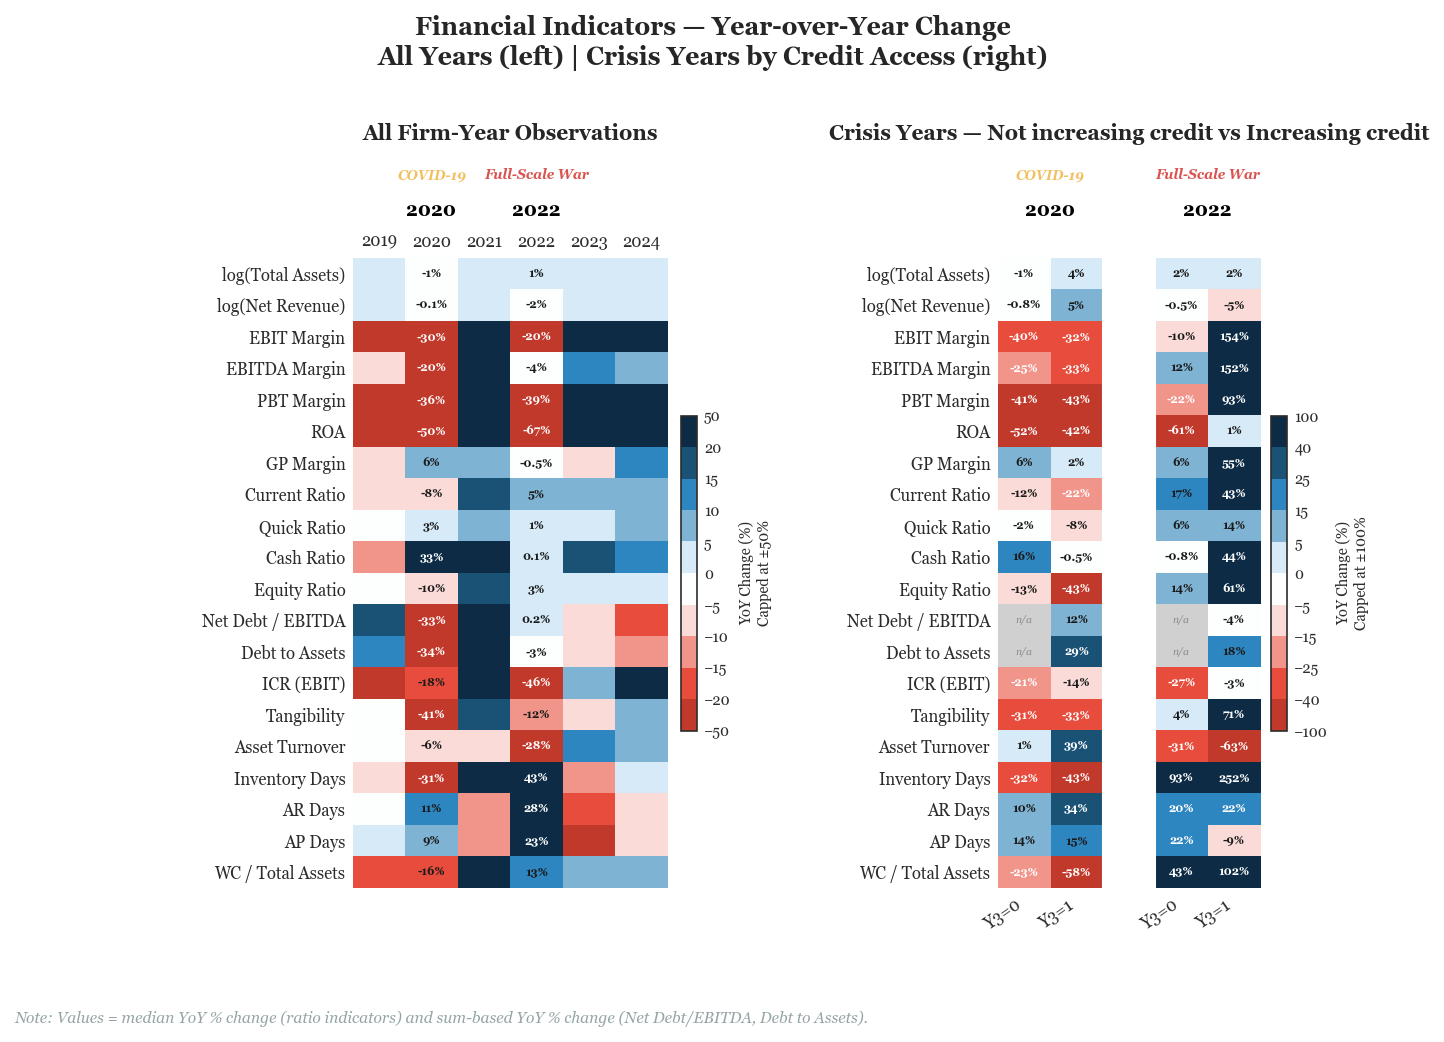

In [9]:
# Heatmap: all years (left) + crisis years by credit (right)
cmap_discrete = mcolors.ListedColormap(HEATMAP_COLORS)
bounds_1 = [-50, -20, -15, -10, -5, 0, 5, 10, 15, 20, 50]
bounds_2 = [-100, -40, -25, -15, -5, 0, 5, 15, 25, 40, 100]
norm_1   = mcolors.BoundaryNorm(bounds_1, cmap_discrete.N)
norm_2   = mcolors.BoundaryNorm(bounds_2, cmap_discrete.N)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 6),
                         gridspec_kw={'wspace': 0.03, 'width_ratios': [6, 5]})

# Panel 1: all observations
ax        = axes[0]
plot_data = yoy_all.dropna(how='all').dropna(axis=1, how='all')
plot_data.columns = [FIN_COLS_LABELS.get(c, c) for c in plot_data.columns]
plot_vals = plot_data.clip(lower=-50, upper=50)
years_list = plot_data.index.tolist()

im1 = ax.imshow(plot_vals.T.values, cmap=cmap_discrete, norm=norm_1, aspect='auto')

n_rows_1 = len(plot_data.columns)
n_cols_1 = len(plot_data.index)
axes[0].set_box_aspect((n_rows_1 / n_cols_1) * 0.6)

for j, year in enumerate(years_list):
    if year in [2020, 2022]:
        for i in range(len(plot_data.columns)):
            val = plot_data.iloc[j, i]
            if pd.isna(val): continue
            color = 'white' if abs(val) > 20 else '#1a1a1a'
            fmt   = f'{val:.1f}%' if abs(val) < 1 else f'{val:.0f}%'
            ax.text(j, i, fmt, ha='center', va='center',
                    fontsize=5.5, color=color, fontweight='bold')

ax.set_xticks(range(len(years_list)))
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_xticklabels(years_list, fontsize=8)
ax.tick_params(which='both', length=0)
ax.set_yticks(range(len(plot_data.columns)))
ax.set_yticklabels(plot_data.columns.tolist(), fontsize=8)
ax.grid(False)
ax.set_axisbelow(False)
for spine in ax.spines.values(): spine.set_visible(False)

ax.text(0.5, 1.18, 'All Firm-Year Observations',
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        transform=ax.transAxes, clip_on=False)
for year, color, label in [(2020, COLORS['accent'], 'COVID-19'), (2022, COLORS['negative'], 'Full-Scale War')]:
    j = years_list.index(year)
    ax.text(j, 1.06, str(year), ha='center', va='bottom', fontsize=9, fontweight='bold',
            color='black', transform=ax.get_xaxis_transform(), clip_on=False)
    ax.text(j, 1.12, label, ha='center', va='bottom', fontsize=6.5, fontweight='bold',
            color=color, style='italic', transform=ax.get_xaxis_transform(), clip_on=False)

cbar1 = plt.colorbar(im1, ax=ax, shrink=0.5, pad=0.02, ticks=bounds_1)
cbar1.set_label('YoY Change (%)\nCapped at ±50%', fontsize=7)
cbar1.ax.tick_params(labelsize=7)

# Panel 2: crisis years by credit group
ax = axes[1]

crisis_yoy_plot = crisis_yoy.copy()
df_left  = crisis_yoy_plot.iloc[:, :2]
df_right = crisis_yoy_plot.iloc[:, 2:]
gap_col  = pd.DataFrame(np.nan, index=crisis_yoy_plot.index, columns=['_gap'])
crisis_with_gap = pd.concat([df_left, gap_col, df_right], axis=1)

rows_crisis = crisis_with_gap.index.tolist()
n_cols      = crisis_with_gap.shape[1]
plot_vals2  = crisis_with_gap.clip(lower=-100, upper=100)

cmap_with_nan = mcolors.ListedColormap(HEATMAP_COLORS)
cmap_with_nan.set_bad(color='#d0d0d0')

im2 = ax.imshow(np.ma.masked_invalid(plot_vals2.values),
                cmap=cmap_with_nan, norm=norm_2, aspect='auto')

n_rows_2 = len(rows_crisis)
n_cols_2  = n_cols
axes[1].set_box_aspect((n_rows_2 / n_cols_2) * 0.6)

ax.grid(False)
ax.set_axisbelow(False)
for spine in ax.spines.values(): spine.set_visible(False)

ax.add_patch(mpatches.Rectangle(
    (1.5, -0.5), 1.0, n_rows_2,
    color='white', zorder=2, transform=ax.transData
))

for plot_j, orig_j in zip([0, 1, 3, 4], range(4)):
    for i in range(len(rows_crisis)):
        val = crisis_yoy_plot.iloc[i, orig_j]
        if pd.isna(val):
            ax.text(plot_j, i, 'n/a', ha='center', va='center',
                    fontsize=5, color='#888888', style='italic', zorder=3)
        else:
            color = 'white' if abs(val) > 20 else '#1a1a1a'
            fmt   = f'{val:.1f}%' if abs(val) < 1 else f'{val:.0f}%'
            ax.text(plot_j, i, fmt, ha='center', va='center',
                    fontsize=5.5, color=color, fontweight='bold', zorder=3)

ax.set_xticks([0, 1, 3, 4])
ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_label_position('bottom')
ax.set_xticklabels(['Y3=0', 'Y3=1', 'Y3=0', 'Y3=1'], fontsize=8, rotation=35, ha='right')
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_yticks(range(len(rows_crisis)))
ax.set_yticklabels(rows_crisis, fontsize=8)
ax.tick_params(which='both', length=0)

ax.text(0.5, 1.18, 'Crisis Years — Not increasing credit vs Increasing credit',
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        transform=ax.transAxes, clip_on=False)
for x_center, year_label, crisis_label, color in [
    (0.5, '2020', 'COVID-19',       COLORS['accent']),
    (3.5, '2022', 'Full-Scale War', COLORS['negative']),
]:
    ax.text(x_center, 1.06, year_label, ha='center', va='bottom', fontsize=9,
            fontweight='bold', color='black',
            transform=ax.get_xaxis_transform(), clip_on=False)
    ax.text(x_center, 1.12, crisis_label, ha='center', va='bottom', fontsize=6.5,
            fontweight='bold', color=color, style='italic',
            transform=ax.get_xaxis_transform(), clip_on=False)

cbar2 = plt.colorbar(im2, ax=ax, shrink=0.5, pad=0.02, ticks=bounds_2)
cbar2.set_label('YoY Change (%)\nCapped at ±100%', fontsize=7)
cbar2.ax.tick_params(labelsize=7)

plt.suptitle('Financial Indicators — Year-over-Year Change\n'
             'All Years (left) | Crisis Years by Credit Access (right)',
             fontsize=12, fontweight='bold', y=1.12)
fig.text(0.01, 0,
         'Note: Values = median YoY % change (ratio indicators) and '
         'sum-based YoY % change (Net Debt/EBITDA, Debt to Assets).',
         fontsize=7.5, color=COLORS['neutral'], style='italic')

plt.subplots_adjust(left=0.08, right=0.95, top=0.85, bottom=0.15)
plt.savefig('eda_heatmap_yoy.png', dpi=150)
plt.show()

## 3. Crisis years heatmap by sector

Computing YoY change in financial indicators for each sector in 2020 and 2022, separately for firms with and without increasing credit.

In [10]:
def calc_crisis_sector(dep_val):
    """YoY change by sector for a given dep_val (0 or 1) in crisis years 2020 and 2022."""
    result = {}
    for year in [2020, 2022]:
        prev = PREV_YEARS[year]
        cols_data = {}
        for sector in SECTOR_ORDER:
            mask_curr = (df['Year'] == year)  & (df['Sector Group'] == sector) & (df[MAIN_DEP_VAR] == dep_val)
            mask_prev = (df['Year'] == prev)  & (df['Sector Group'] == sector) & (df[MAIN_DEP_VAR] == dep_val)

            curr_med = df[mask_curr][FIN_COLS_W].median()
            prev_med = df[mask_prev][FIN_COLS_W].median()
            curr_sum = df[mask_curr][SUM_COLS].sum()
            prev_sum = df[mask_prev][SUM_COLS].sum()

            yoy_col = ((curr_med - prev_med) / prev_med.abs() * 100).round(1)
            for col in SUM_COLS:
                yoy_col[col] = ((curr_sum[col] - prev_sum[col]) / abs(prev_sum[col]) * 100
                                ).round(1) if prev_sum[col] != 0 else np.nan
            cols_data[sector] = yoy_col

        sector_df = pd.DataFrame(cols_data)
        sector_df.index = [FIN_COLS_LABELS.get(c, c) for c in sector_df.index]
        result[year] = sector_df
    return result


crisis_sector_y1 = calc_crisis_sector(dep_val=1)  # Y3 = 1
crisis_sector_y0 = calc_crisis_sector(dep_val=0)  # Y3 = 0

print('Crisis 2020 by Sector (Y3 = 1):')
print(crisis_sector_y1[2020].round(1).to_string())
print('\nCrisis 2022 by Sector (Y3 = 1):')
print(crisis_sector_y1[2022].round(1).to_string())

Crisis 2020 by Sector (Y3 = 1):
                   Agriculture  Manufacturing  Wholesale & Retail Trade  Energy  Mining  Other
log(Total Assets)          8.7            3.1                       1.9     0.5    -2.8    3.7
log(Net Revenue)          11.4            1.2                       0.6    -4.1    -9.2    0.3
EBIT Margin              111.0           -4.3                       2.7   -39.6    44.2  -38.6
EBITDA Margin             55.1            5.2                       4.1   -48.7    25.6  -20.0
PBT Margin               -84.8          -12.1                     -21.2   -97.9    54.0  -59.1
ROA                      -79.4          -24.8                     -20.4   -96.8   -55.7  -84.8
GP Margin                  5.5            9.0                       6.3     1.6    77.4   -6.3
Current Ratio            -57.8           -6.8                      -5.6    -0.2    -4.9   -5.0
Quick Ratio              -29.8           -8.1                     -11.6     3.5   -10.0   -8.3
Cash Ratio        

/var/folders/02/hb5ht0zx44137l9lqlhhqg380000gn/T/ipykernel_56252/202538082.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


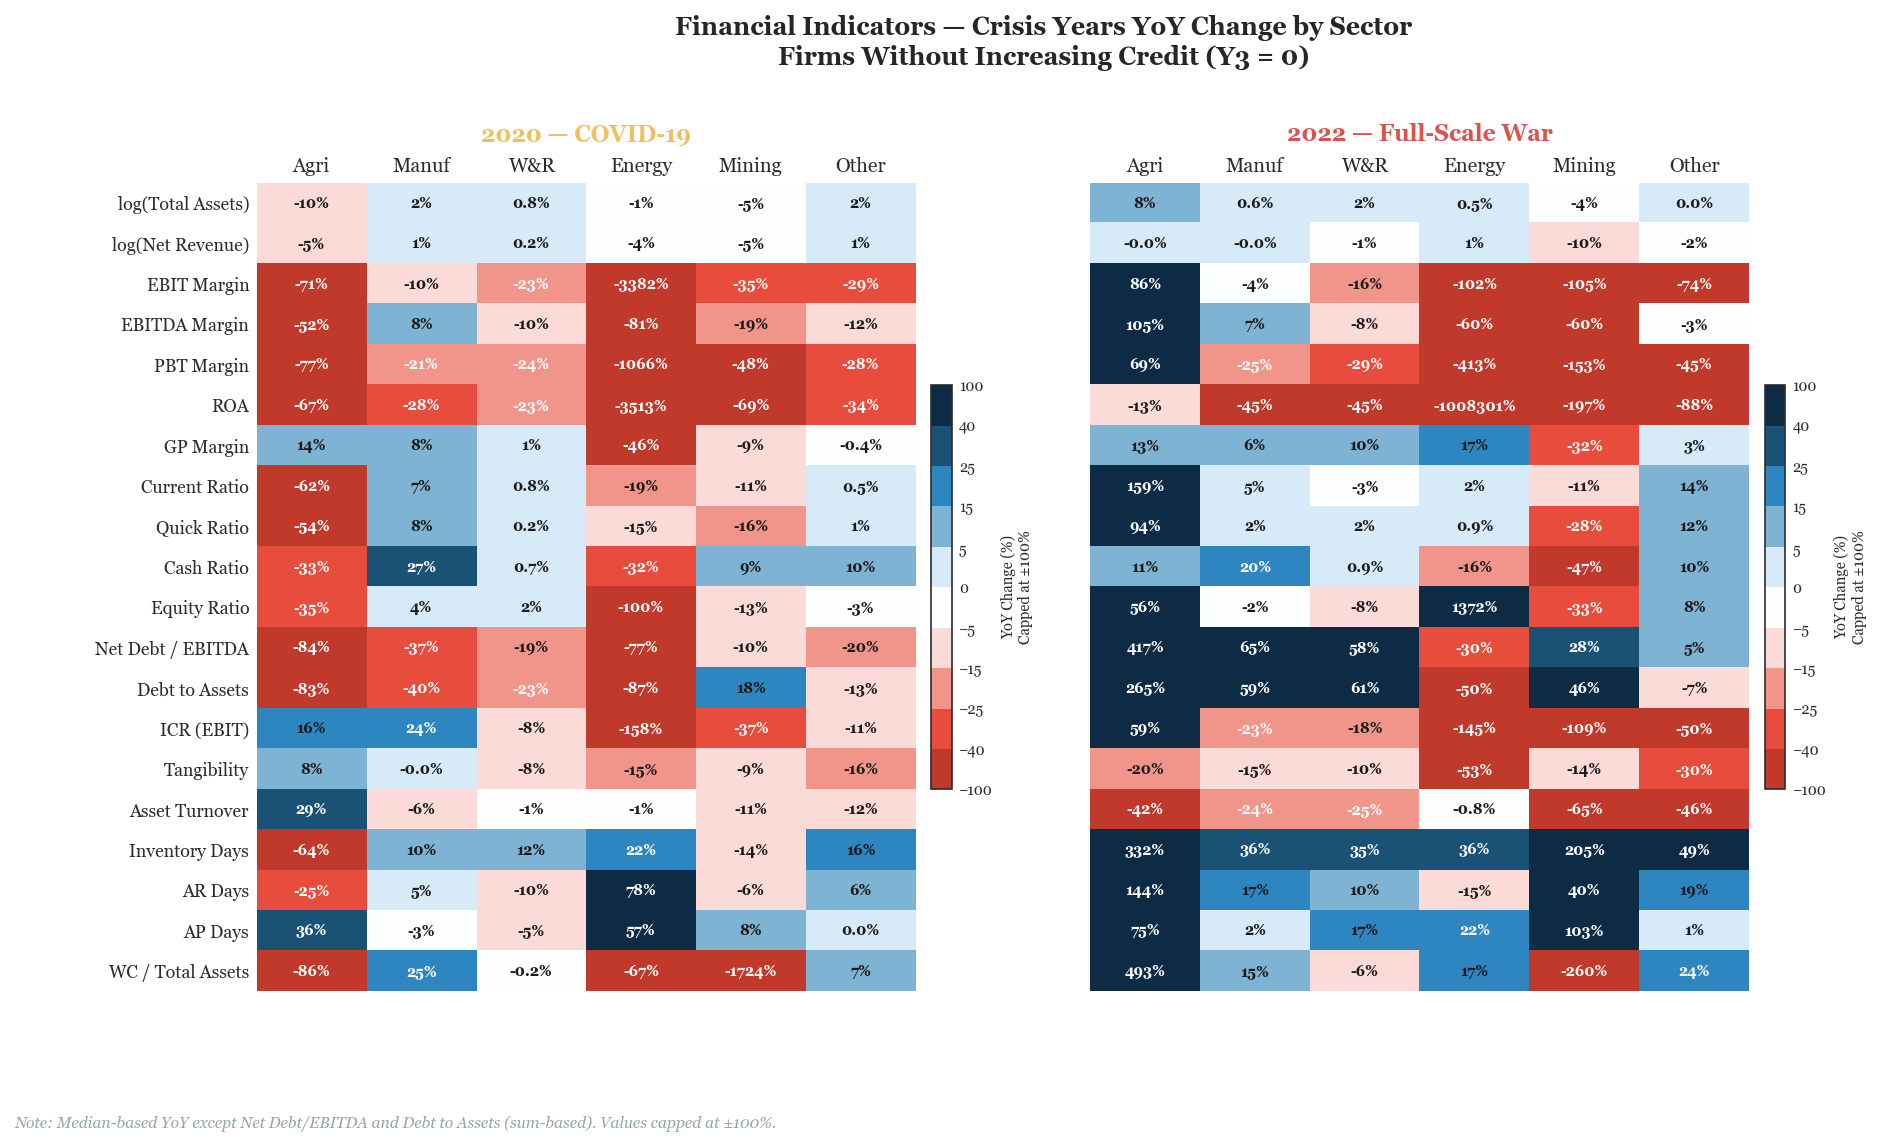

/var/folders/02/hb5ht0zx44137l9lqlhhqg380000gn/T/ipykernel_56252/202538082.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


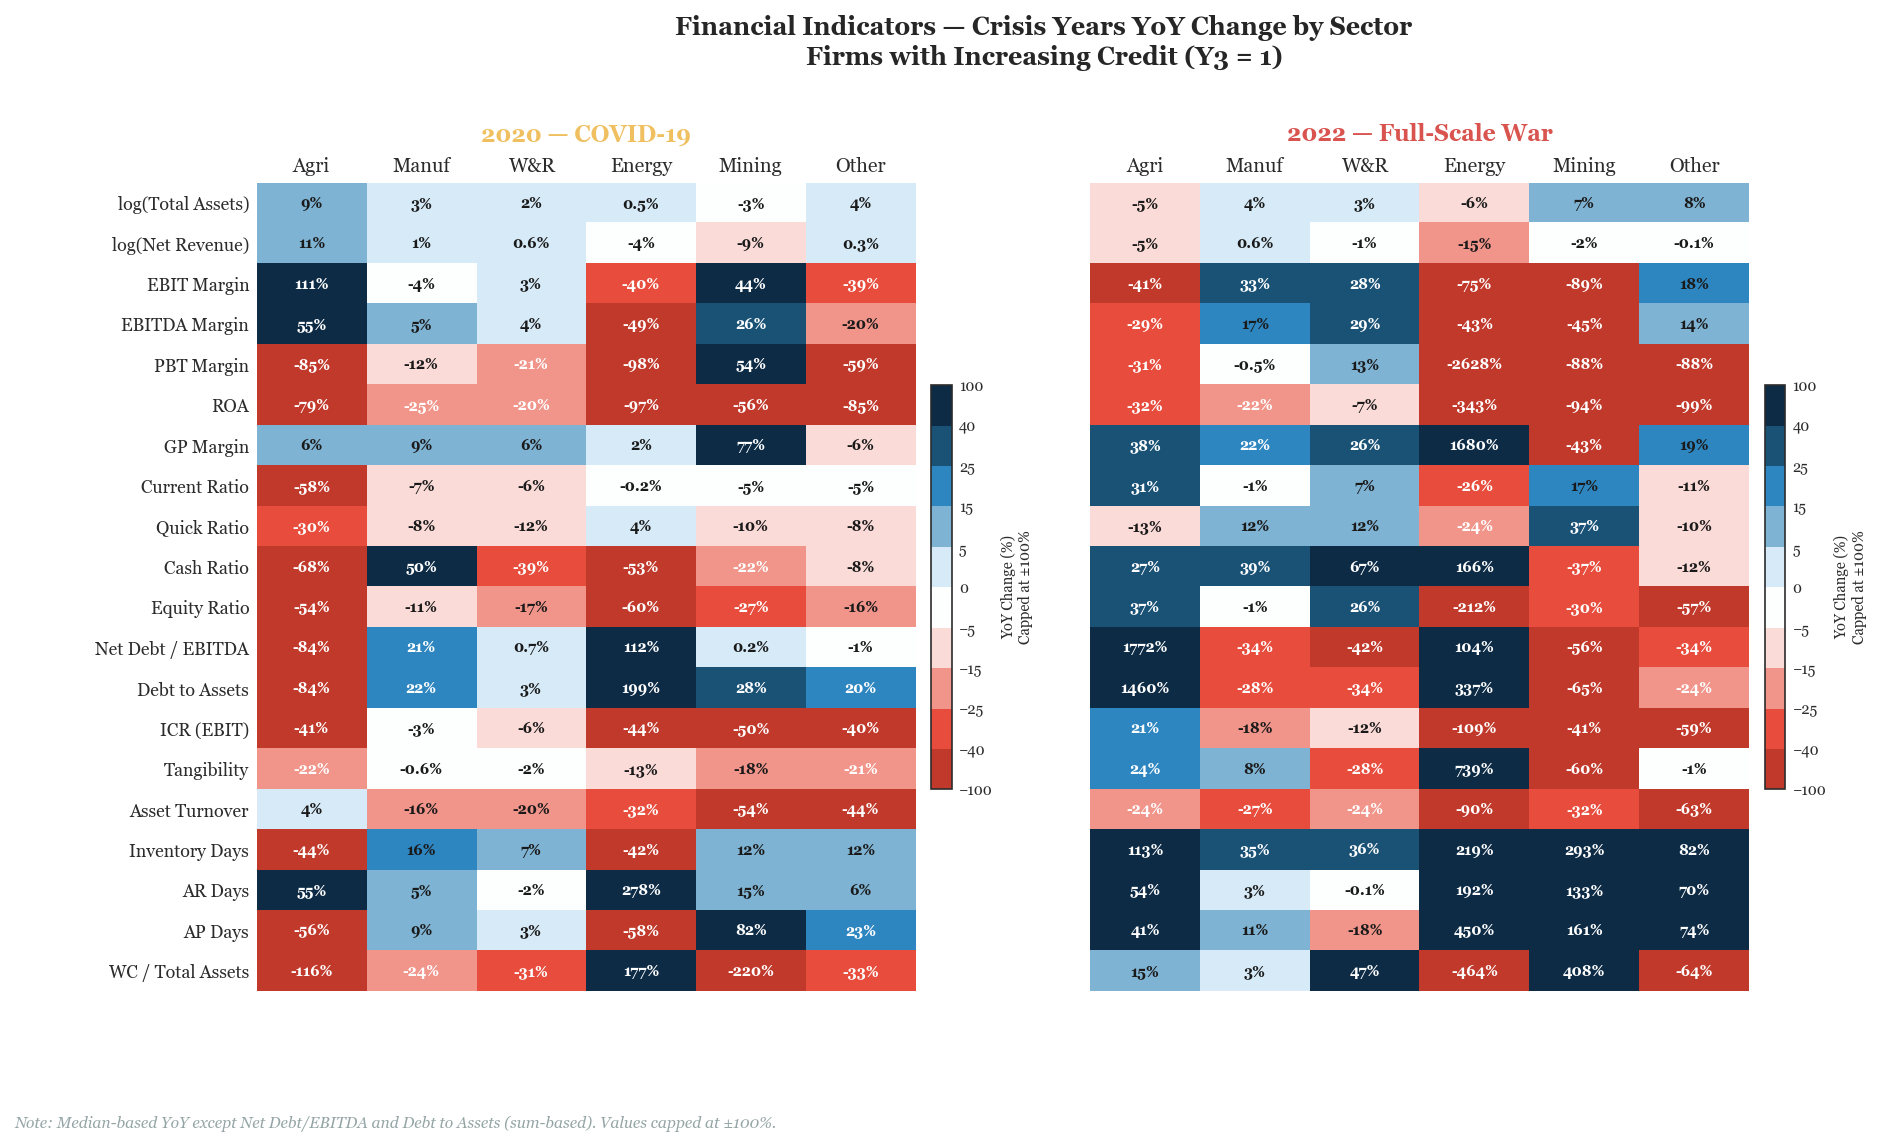

In [11]:
# Sector heatmaps for Y3=1 and Y3=0
cmap_sector = mcolors.ListedColormap(HEATMAP_COLORS)
cmap_sector.set_bad(color='#e8e8e8')
bounds_2    = [-100, -40, -25, -15, -5, 0, 5, 15, 25, 40, 100]
norm_sector = mcolors.BoundaryNorm(bounds_2, cmap_sector.N)
cols_short  = [SECTOR_SHORT[s] for s in SECTOR_ORDER]

for data_dict, title_main, fname in [
    (crisis_sector_y0, 'Firms Without Increasing Credit (Y3 = 0)', 'eda_heatmap_sector_no_credit.png'),
    (crisis_sector_y1, 'Firms with Increasing Credit (Y3 = 1)',    'eda_heatmap_sector_credit.png'),
]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7), gridspec_kw={'wspace': 0.05})

    for ax, year, title_year, color_crisis in [
        (axes[0], 2020, '2020 — COVID-19',      COLORS['accent']),
        (axes[1], 2022, '2022 — Full-Scale War', COLORS['negative']),
    ]:
        data      = data_dict[year]
        plot_data = np.ma.masked_invalid(data.clip(lower=-100, upper=100).values)
        im = ax.imshow(plot_data, cmap=cmap_sector, norm=norm_sector, aspect='auto')

        for i in range(len(data.index)):
            for j in range(len(SECTOR_ORDER)):
                val = data.iloc[i, j]
                if pd.isna(val):
                    ax.text(j, i, 'n/a', ha='center', va='center',
                            fontsize=5.5, color='#888888', style='italic')
                    continue
                color = 'white' if abs(val) > 20 else '#1a1a1a'
                fmt   = f'{val:.1f}%' if abs(val) < 1 else f'{val:.0f}%'
                ax.text(j, i, fmt, ha='center', va='center',
                        fontsize=7, color=color, fontweight='bold')

        ax.set_xticks(range(len(SECTOR_ORDER)))
        ax.xaxis.set_ticks_position('top')
        ax.xaxis.set_label_position('top')
        ax.set_xticklabels(cols_short, fontsize=9.5)
        ax.tick_params(which='both', length=0)
        ax.set_yticks(range(len(data.index)))
        ax.set_yticklabels(data.index.tolist() if ax == axes[0] else [], fontsize=8.5)
        ax.grid(False)
        for spine in ax.spines.values(): spine.set_visible(False)

        cbar = plt.colorbar(im, ax=ax, shrink=0.5, pad=0.02, ticks=bounds_2)
        cbar.set_label('YoY Change (%)\nCapped at ±100%', fontsize=7)
        cbar.ax.tick_params(labelsize=7)
        ax.set_title(title_year, fontsize=11, fontweight='bold', color=color_crisis, pad=20)

    fig.suptitle(f'Financial Indicators — Crisis Years YoY Change by Sector\n{title_main}',
                 fontsize=12, fontweight='bold', y=1.04)
    fig.text(0.01, -0.02,
             'Note: Median-based YoY except Net Debt/EBITDA and Debt to Assets (sum-based). '
             'Values capped at ±100%.',
             fontsize=7.5, color=COLORS['neutral'], style='italic')
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.show()

## 4. Share of firms with increasing credit in crisis years by sector

Comparing Y3 rates across sectors in 2020 (COVID-19) and 2022 (Full-Scale War).

In [12]:
print('Share of Firms with Increasing Credit (%) by Sector — Crisis Years')

rows = []
for sector in SECTOR_ORDER:
    row = {'Sector': sector}
    for year in [2020, 2022]:
        temp = df[(df['Year'] == year) & (df['Sector Group'] == sector)][MAIN_DEP_VAR].dropna()
        row[str(year)] = round(temp.mean() * 100, 1)
    rows.append(row)

for year in [2020, 2022]:
    avg = df[df['Year'] == year][MAIN_DEP_VAR].mean() * 100
    print(f'Overall average {year}: {avg:.1f}%')

print()
print(pd.DataFrame(rows).to_string(index=False))

Share of Firms with Increasing Credit (%) by Sector — Crisis Years
Overall average 2020: 11.5%
Overall average 2022: 13.0%

                  Sector  2020  2022
             Agriculture  14.9  37.1
           Manufacturing  18.9  17.2
Wholesale & Retail Trade  17.3  15.0
                  Energy  19.3  13.6
                  Mining   9.2   4.4
                   Other   5.8   2.9


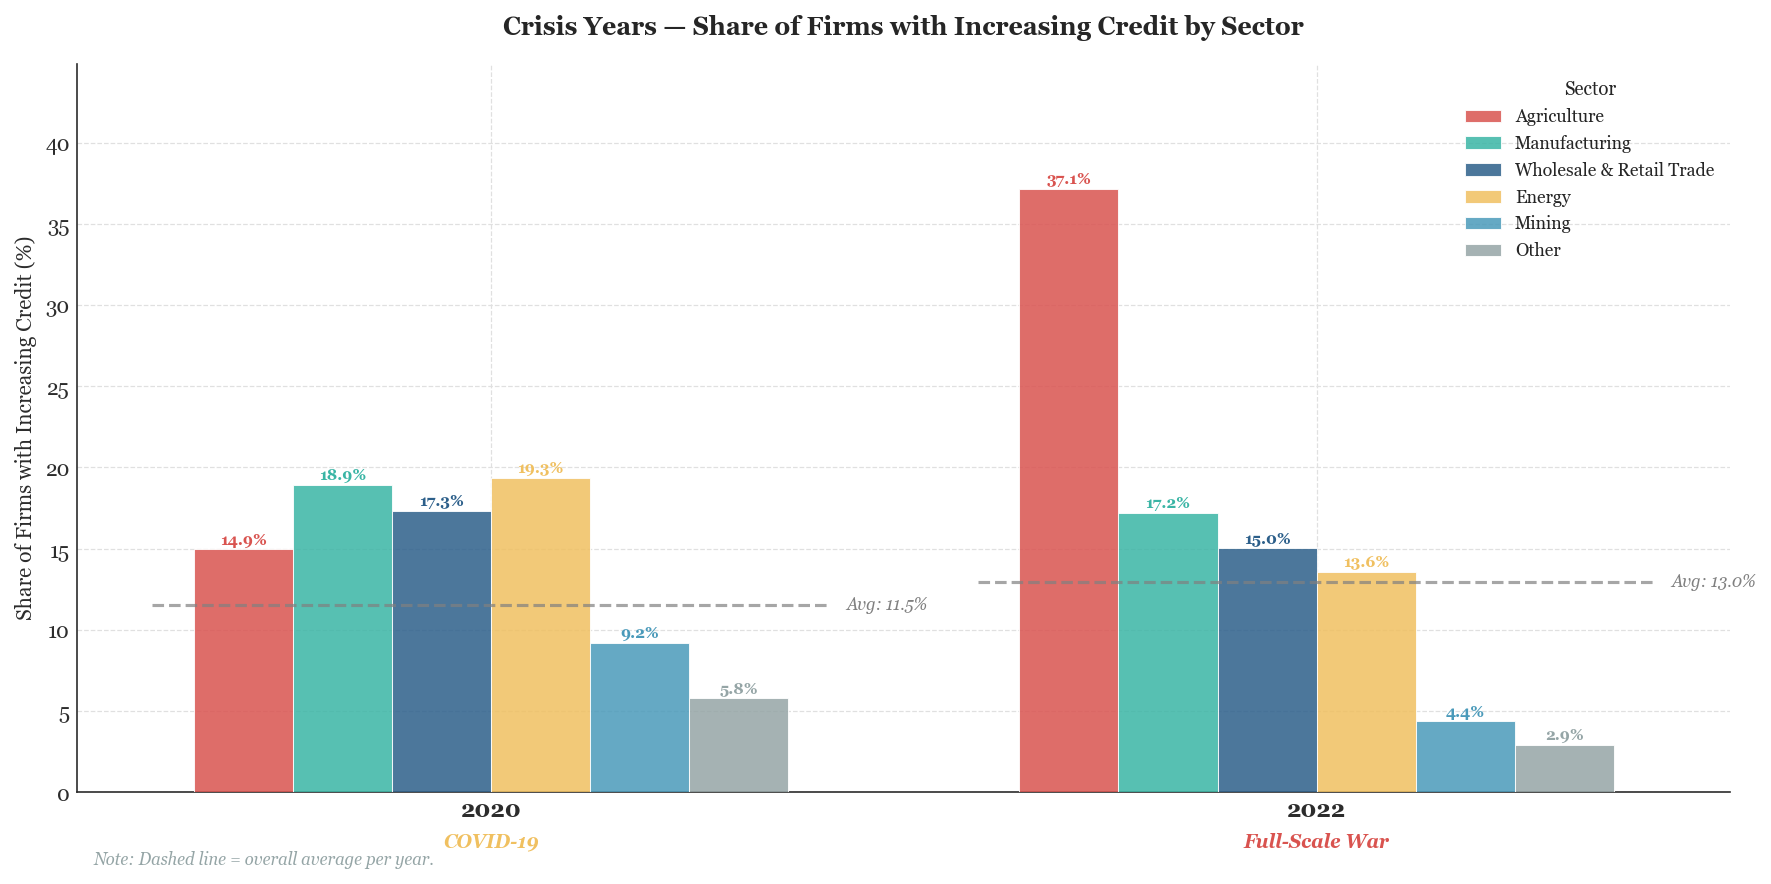

In [13]:
# Bar chart: credit share by sector in crisis years
fig, ax = plt.subplots(figsize=(12, 6))

years_crisis = [2020, 2022]
n_sectors    = len(SECTOR_ORDER)
bar_width    = 0.12
x            = np.arange(len(years_crisis))

for i, sector in enumerate(SECTOR_ORDER):
    shares = [df[(df['Year'] == y) & (df['Sector Group'] == sector)][MAIN_DEP_VAR].dropna().mean() * 100
              for y in years_crisis]
    offset = (i - n_sectors / 2 + 0.5) * bar_width
    bars   = ax.bar(x + offset, shares, width=bar_width, color=SECTOR_COLORS[sector],
                    alpha=0.85, label=sector, edgecolor='white', linewidth=0.5, zorder=3)
    for bar, val in zip(bars, shares):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=7.5,
                color=SECTOR_COLORS[sector], fontweight='bold')

for j, year in enumerate(years_crisis):
    avg = df[df['Year'] == year][MAIN_DEP_VAR].mean() * 100
    ax.plot([x[j] - n_sectors * bar_width / 2 - 0.05, x[j] + n_sectors * bar_width / 2 + 0.05],
            [avg, avg], color='grey', linewidth=1.5, linestyle='--', alpha=0.7, zorder=5)
    ax.text(x[j] + n_sectors * bar_width / 2 + 0.07, avg, f'Avg: {avg:.1f}%',
            va='center', fontsize=8, color='grey', style='italic')

for j, (year, label, color) in enumerate([
    (2020, 'COVID-19',       COLORS['accent']),
    (2022, 'Full-Scale War', COLORS['negative']),
]):
    ax.text(x[j], -2.5, label, ha='center', fontsize=9,
            color=color, fontweight='bold', style='italic', va='top', clip_on=False)

ax.set_xticks(x)
ax.set_xticklabels(years_crisis, fontsize=11, fontweight='bold')
ax.set_ylabel('Share of Firms with Increasing Credit (%)', fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.legend(fontsize=8.5, loc='upper right', title='Sector', title_fontsize=9)
ax.set_title('Crisis Years — Share of Firms with Increasing Credit by Sector',
             fontsize=12, fontweight='bold')
ax.text(0.01, -0.10, 'Note: Dashed line = overall average per year.',
        transform=ax.transAxes, fontsize=8, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.savefig('eda_crisis_credit_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Regional credit access — before and after full-scale war

Comparing Y3 rates across region groups in two periods: pre-war (2019–2021) and war period (2022–2024).

In [14]:
def get_region_pre2022(row):
    return 'Frontline 2014' if row['Region'] in FRONTLINE_2014 else 'Other Regions'

def get_region_post2022(row):
    if row['Region'] in FRONTLINE_2014:
        return 'Frontline 2014'
    elif row['Region'] in FRONTLINE_2022:
        return 'Frontline 2022'
    return 'Other Regions'


df_pre  = df[df['Year'] < 2022].copy()
df_post = df[df['Year'] >= 2022].copy()
df_pre['Region_Group_Period']  = df_pre.apply(get_region_pre2022,  axis=1)
df_post['Region_Group_Period'] = df_post.apply(get_region_post2022, axis=1)

region_order_pre  = ['Frontline 2014', 'Other Regions']
region_order_post = ['Frontline 2022', 'Frontline 2014', 'Other Regions']

print('Regional Credit Access — Before and After Full-Scale War')
for period, data, order in [
    ('Before Full-Scale War (2019–2021)', df_pre,  region_order_pre),
    ('Full-Scale War Period (2022–2024)', df_post, region_order_post),
]:
    print(f'\n{period}')
    print('-' * 65)
    rows = []
    for region in order:
        temp = data[data['Region_Group_Period'] == region][MAIN_DEP_VAR].dropna()
        rows.append({'Region Group': region, 'N obs': len(temp),
                     'Credit=1 (%)': round((temp == 1).mean() * 100, 1),
                     'Credit=0 (%)': round((temp == 0).mean() * 100, 1)})
    print(pd.DataFrame(rows).to_string(index=False))

Regional Credit Access — Before and After Full-Scale War

Before Full-Scale War (2019–2021)
-----------------------------------------------------------------
  Region Group  N obs  Credit=1 (%)  Credit=0 (%)
Frontline 2014    857           7.1          92.9
 Other Regions  27396          13.1          86.9

Full-Scale War Period (2022–2024)
-----------------------------------------------------------------
  Region Group  N obs  Credit=1 (%)  Credit=0 (%)
Frontline 2022   4770          12.7          87.3
Frontline 2014    406           5.4          94.6
 Other Regions  27084          12.1          87.9


/var/folders/02/hb5ht0zx44137l9lqlhhqg380000gn/T/ipykernel_56252/2483304201.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


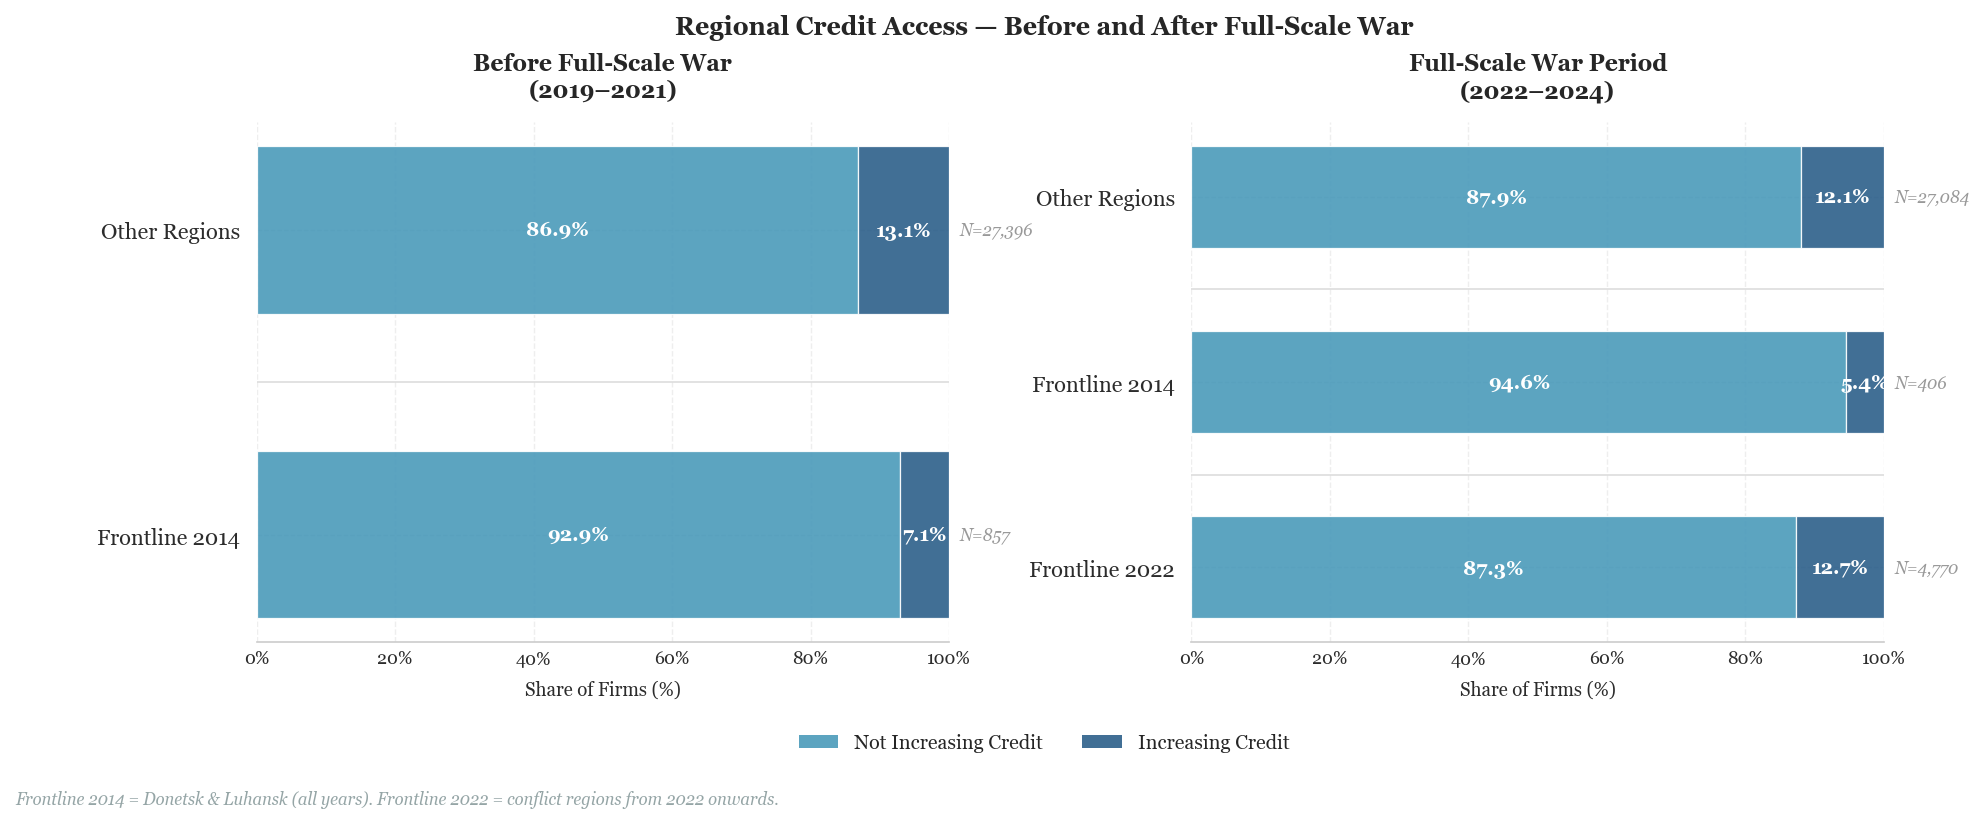

In [15]:
# Stacked horizontal bar chart: credit share by region group and period
COLOR_NO  = COLORS['secondary']
COLOR_YES = COLORS['primary']
BAR_H     = 0.55

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'wspace': 0.35})

for ax, data, order, title in [
    (axes[0], df_pre,  region_order_pre,  'Before Full-Scale War\n(2019–2021)'),
    (axes[1], df_post, region_order_post, 'Full-Scale War Period\n(2022–2024)'),
]:
    rows = []
    for region in order:
        temp = data[data['Region_Group_Period'] == region][MAIN_DEP_VAR].dropna()
        rows.append({'Region': region,
                     'Credit=1': (temp == 1).mean() * 100,
                     'Credit=0': (temp == 0).mean() * 100,
                     'N': len(temp)})
    bar_df = pd.DataFrame(rows)
    y = np.arange(len(order))

    ax.barh(y, bar_df['Credit=0'], height=BAR_H, color=COLOR_NO, alpha=0.9,
            edgecolor='white', linewidth=0.6, zorder=3)
    ax.barh(y, bar_df['Credit=1'], left=bar_df['Credit=0'], height=BAR_H,
            color=COLOR_YES, alpha=0.9, edgecolor='white', linewidth=0.6, zorder=3)

    for i, (v0, v1) in enumerate(zip(bar_df['Credit=0'], bar_df['Credit=1'])):
        if v0 > 5:
            ax.text(v0 / 2, i, f'{v0:.1f}%', ha='center', va='center',
                    fontsize=9.5, color='white', fontweight='bold')
        if v1 > 2:
            ax.text(v0 + v1 / 2, i, f'{v1:.1f}%', ha='center', va='center',
                    fontsize=9.5, color='white', fontweight='bold')

    for i, n in enumerate(bar_df['N']):
        ax.text(101.5, i, f'N={n:,}', ha='left', va='center',
                fontsize=8, color='#999999', style='italic')

    ax.set_yticks(y)
    ax.set_yticklabels(order, fontsize=10.5)
    ax.tick_params(axis='y', length=0, pad=8)
    ax.set_xlim(0, 100)
    ax.set_xlabel('Share of Firms (%)', fontsize=9, labelpad=6)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.tick_params(axis='x', length=0, labelsize=8.5)
    for yi in np.arange(0.5, len(order) - 0.5, 1):
        ax.axhline(yi, color='#dddddd', linewidth=0.8, zorder=1)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.xaxis.grid(True, color='#eeeeee', linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12)

legend_elements = [
    mpatches.Patch(facecolor=COLOR_NO,  alpha=0.9, label='Not Increasing Credit'),
    mpatches.Patch(facecolor=COLOR_YES, alpha=0.9, label='Increasing Credit'),
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.08),
           ncol=2, fontsize=9.5, frameon=False)

plt.suptitle('Regional Credit Access — Before and After Full-Scale War',
             fontsize=12, fontweight='bold', y=1.04)
fig.text(0.01, -0.13,
         'Frontline 2014 = Donetsk & Luhansk (all years). '
         'Frontline 2022 = conflict regions from 2022 onwards.',
         fontsize=8, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.savefig('eda_regional_credit_periods.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Frontline dummies — credit access by sector

Reporting Y3 rates within frontline regions (2014 and 2022 waves) broken down by sector.

In [16]:
print('Frontline Regions — Share of Firms with Increasing Credit by Sector')

rows = []
for dummy_col, label in [('Frontline_2014', 'Frontline 2014'), ('Frontline_2022', 'Frontline 2022')]:
    avg = df[df[dummy_col] == 1][MAIN_DEP_VAR].mean() * 100
    row = {'Frontline Group': label, 'Overall Avg (%)': round(avg, 1)}
    for sector in SECTOR_ORDER:
        temp = df[(df[dummy_col] == 1) & (df['Sector Group'] == sector)][MAIN_DEP_VAR].dropna()
        row[sector] = round(temp.mean() * 100, 1) if len(temp) > 0 else None
    rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))

Frontline Regions — Share of Firms with Increasing Credit by Sector
Frontline Group  Overall Avg (%)  Agriculture  Manufacturing  Wholesale & Retail Trade  Energy  Mining  Other
 Frontline 2014              6.6         12.4           10.1                      15.0     8.7     4.2    0.8
 Frontline 2022             12.7         24.6           14.4                      14.2    10.8     0.0    3.8


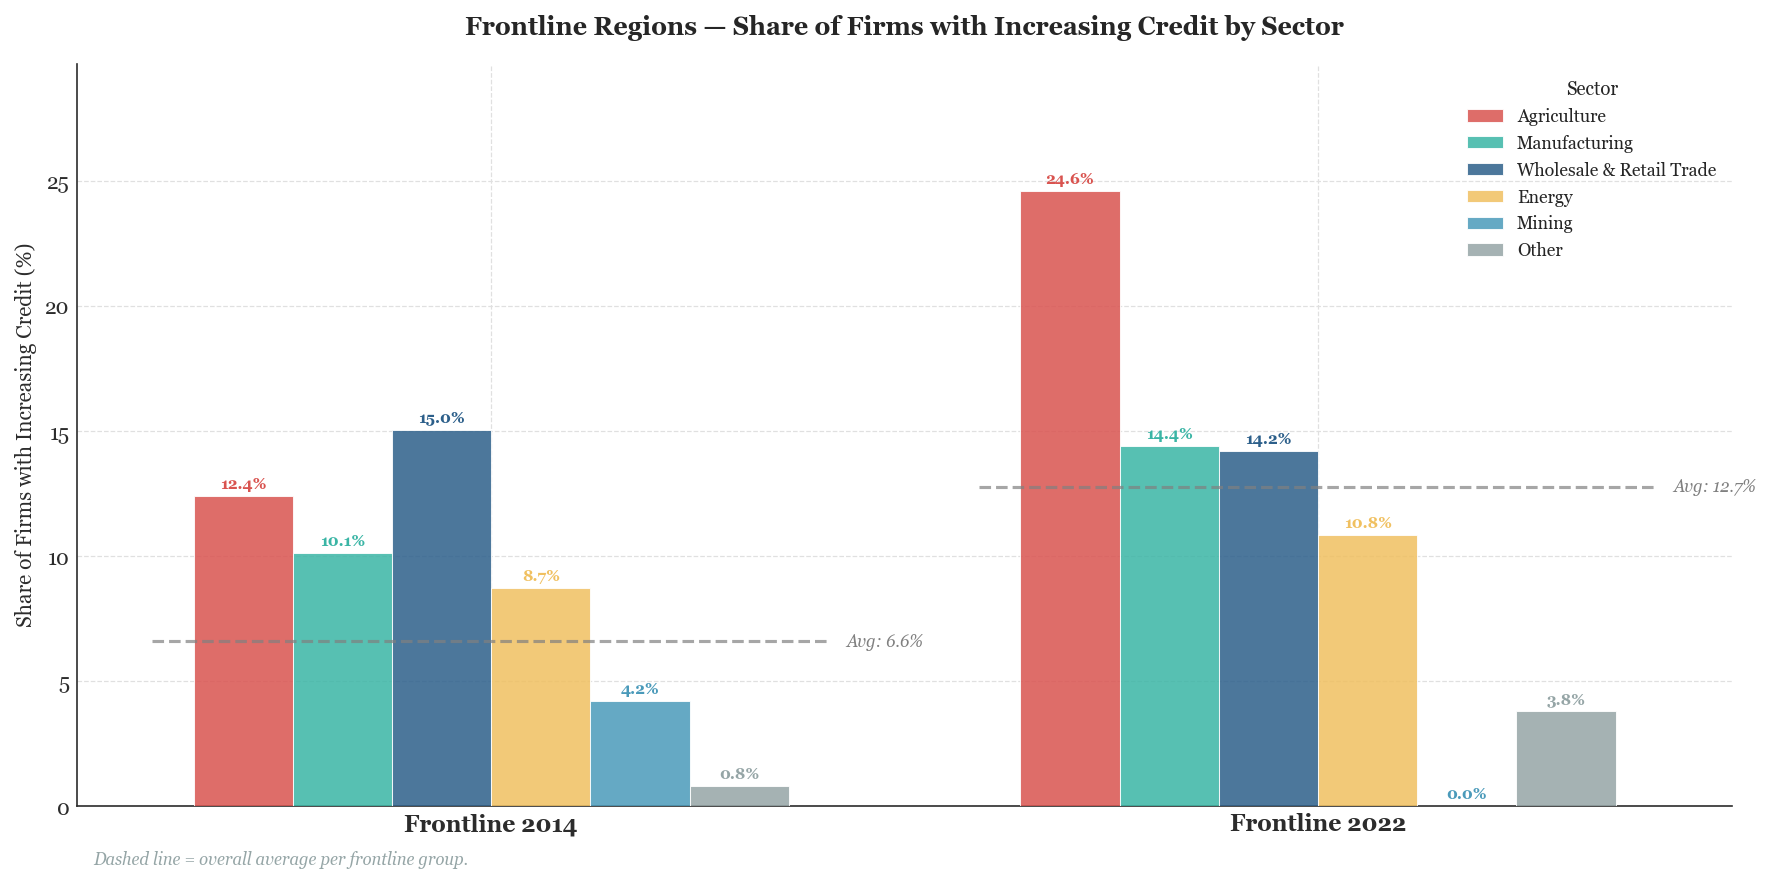

In [17]:
# Bar chart: frontline credit share by sector
frontline_vars = [('Frontline_2014', 'Frontline 2014'), ('Frontline_2022', 'Frontline 2022')]

fig, ax = plt.subplots(figsize=(12, 6))

n_sectors = len(SECTOR_ORDER)
bar_width  = 0.12
x          = np.arange(len(frontline_vars))

for i, sector in enumerate(SECTOR_ORDER):
    shares = []
    for dummy_col, _ in frontline_vars:
        temp  = df[(df[dummy_col] == 1) & (df['Sector Group'] == sector)][MAIN_DEP_VAR].dropna()
        shares.append(temp.mean() * 100 if len(temp) > 0 else np.nan)

    offset = (i - n_sectors / 2 + 0.5) * bar_width
    bars   = ax.bar(x + offset, shares, width=bar_width, color=SECTOR_COLORS[sector],
                    alpha=0.85, label=sector, edgecolor='white', linewidth=0.5, zorder=3)
    for bar, val in zip(bars, shares):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', fontsize=7.5,
                    color=SECTOR_COLORS[sector], fontweight='bold')

for j, (dummy_col, _) in enumerate(frontline_vars):
    avg = df[df[dummy_col] == 1][MAIN_DEP_VAR].mean() * 100
    ax.plot([x[j] - n_sectors * bar_width / 2 - 0.05, x[j] + n_sectors * bar_width / 2 + 0.05],
            [avg, avg], color='grey', linewidth=1.5, linestyle='--', alpha=0.7, zorder=5)
    ax.text(x[j] + n_sectors * bar_width / 2 + 0.07, avg, f'Avg: {avg:.1f}%',
            va='center', fontsize=8, color='grey', style='italic')

ax.set_xticks(x)
ax.set_xticklabels([label for _, label in frontline_vars], fontsize=11, fontweight='bold')
ax.set_ylabel('Share of Firms with Increasing Credit (%)', fontsize=10)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.legend(fontsize=8.5, loc='upper right', title='Sector', title_fontsize=9)
ax.set_title('Frontline Regions — Share of Firms with Increasing Credit by Sector',
             fontsize=12, fontweight='bold')
ax.text(0.01, -0.08, 'Dashed line = overall average per frontline group.',
        transform=ax.transAxes, fontsize=8, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.savefig('eda_frontline_credit_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()